#Imbalanced Data

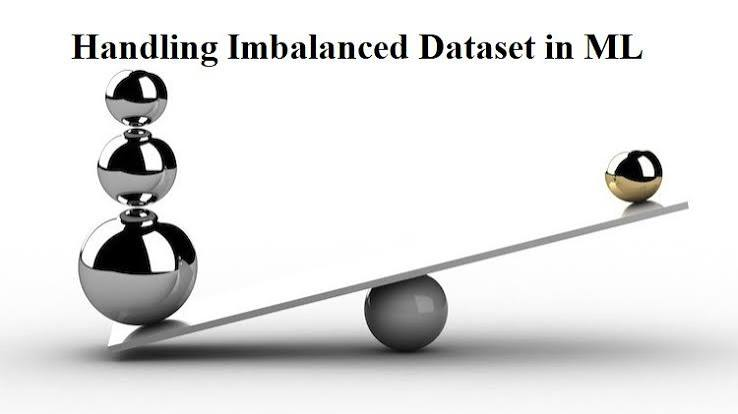

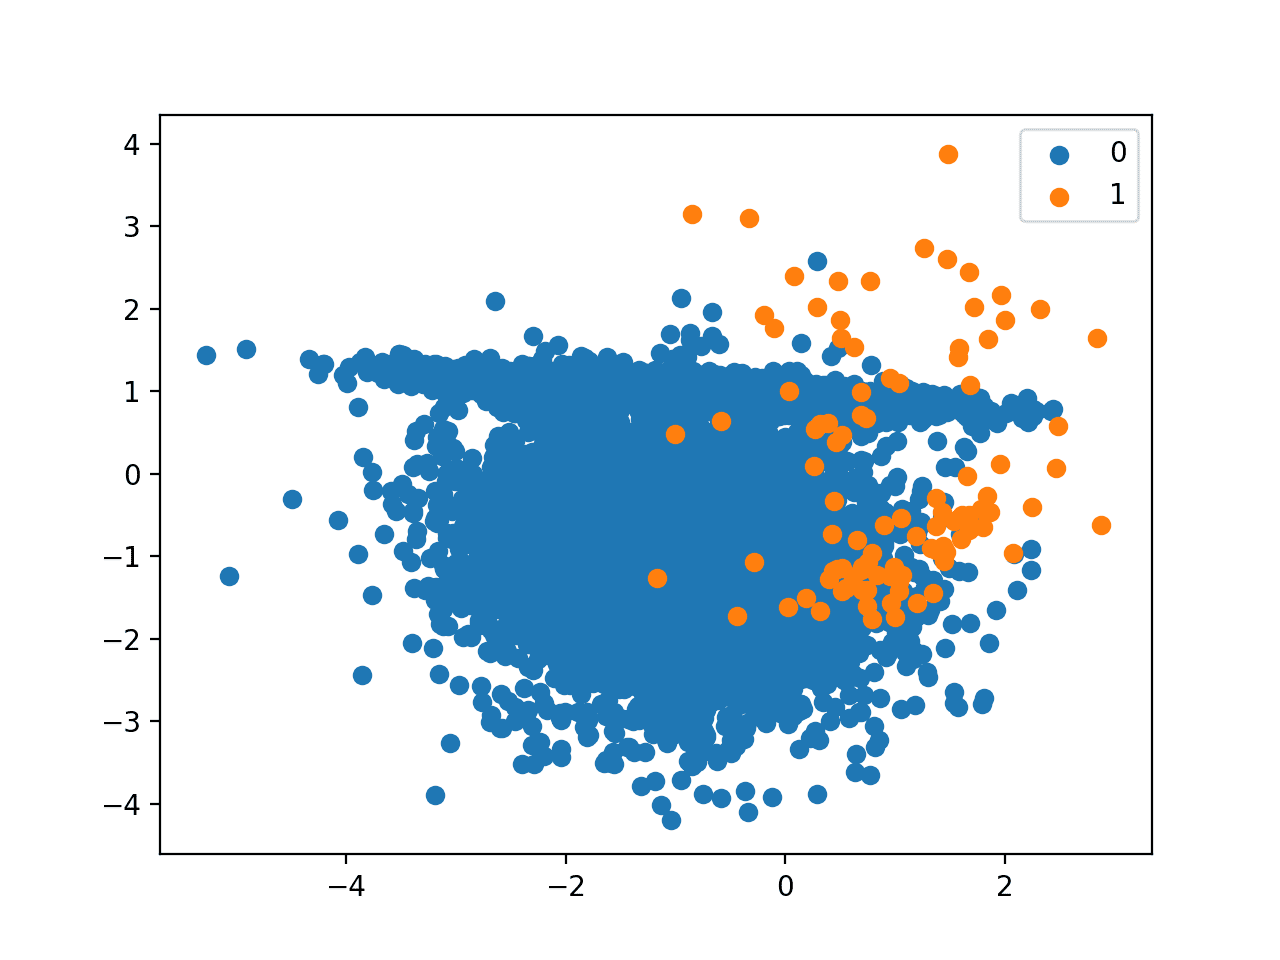

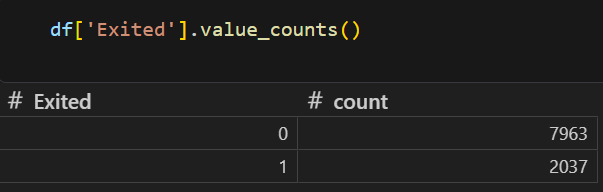

predicts -- accuracy 99%

model useless



##How To handle the imbalanced data?


1. change data before it reach to model

2. Model level (class weight)






### Change Data ?
1. Oversampling
2. undersampling


Oversampling and undersampling are data preparation techniques used in machine learning to fix class imbalance

#1. Oversampling
      1. Random oversampling

      2. SMOTE

Random oversampling is a data preprocessing technique that balances imbalanced datasets by randomly duplicating examples from the minority class until a desired class distribution is reached

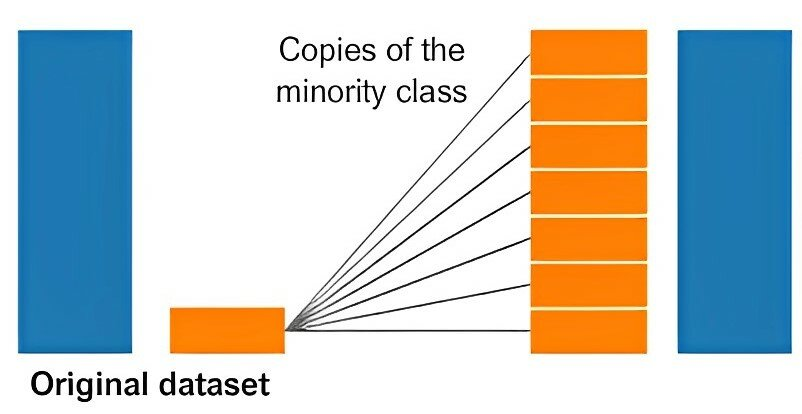




```
X = df.drop("Exited", axis=1)
y = df["Exited"]


print(y.value_counts())
```







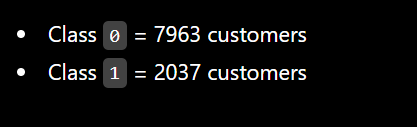



```
X = df.drop("Exited", axis=1)
y = df["Exited"]


print(y.value_counts())
```



Random Oversampling



```
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train,
    y_train
)
```

```
print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(y_train_resampled.value_counts())
```

```
Before:
0    6370
1    1630

After:
0    6370
1    6370
```

## SMOTE

is a popular machine learning method used to fix class imbalance in datasets

1. Identifies imbalance: It finds the minority class (the category with fewer data points).

2. Finds neighbors: For each minority data point, it finds the k-nearest neighbors using feature distance.

3. Creates synthetic data: It picks a random neighbor and builds a new, artificial data point on the line between the original point and that neighbor.

4. Avoids pure duplication: Instead of copying exact duplicates (which causes overfitting), it creates unique, interpolated data points.

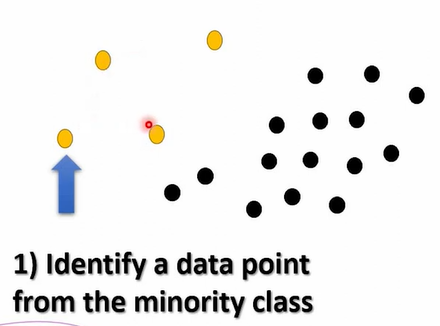

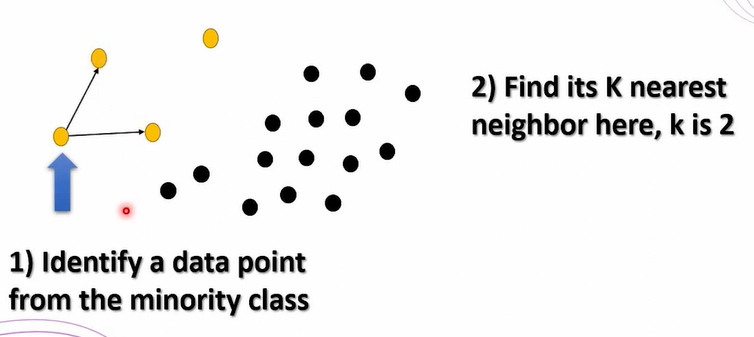

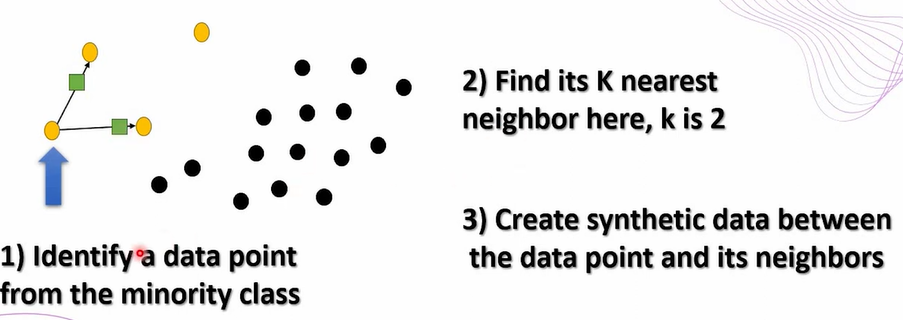

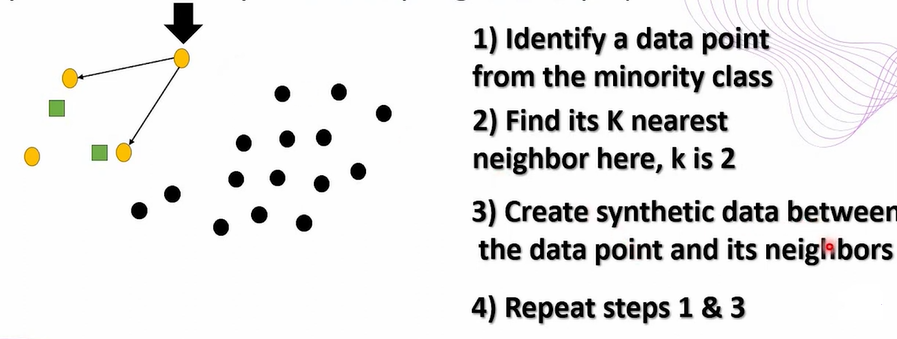

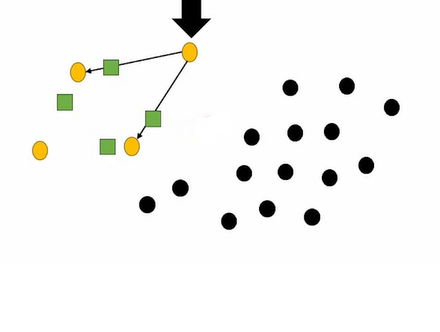

1. Train/Test Split

```
from sklearn.model_selection import train_test_split

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```
2. Apply SMOTE

```
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
```





3. Distribution

```
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
```

```
Before SMOTE:

0    6370
1    1630

After SMOTE:

0    6370
1    6370
```

# Random Undersampling

Random undersampling is a data preprocessing technique that randomly deletes examples from the majority class to balance class distribution in an imbalanced dataset

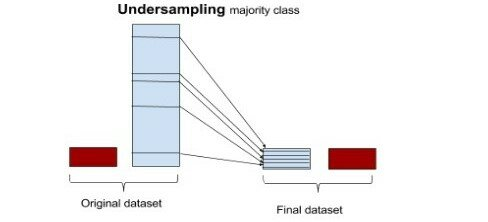

1. Train/Test split

```
from sklearn.model_selection import train_test_split

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```
2. Random Undersampling

```
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(
    X_train,
    y_train
)
```
3. Distrebution

```
print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(y_train_under.value_counts())
```

```
Before:

0    6370
1    1630


After:

0    1630
1    1630
```

#Class Weight (Model Level)

Exited

0  =  7963

1  =  2037



---------------------------


1. indentify the class weight

```
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
classes
```
array([0, 1])

----------------------------

2. get the weight of each unique value y

```
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
weights
```
array([0.62794349, 2.45398773])



-------------------------




## How Can I apply this ?

```
clf = RandomForestClassifier(
    class_weight='balanced'
)
LogisticRegression(class_weight='balanced')
DecisionTreeClassifier(class_weight='balanced')
SVC(class_weight='balanced')
```